In [1]:
import os
import pandas as pd
import numpy as np

# This tells Jupyter to show us every single column without hiding them
pd.set_option('display.max_columns', None)

# Define where our raw data is sitting relative to this notebook folder
RAW_DATA_PATH = "../data/raw/Fraud_Data.csv"

# Load the file into a memory table called a DataFrame
ecom_df = pd.read_csv(RAW_DATA_PATH)

print(f"[SUCCESS] Loaded dataset!")
print(f"Total Rows (Transactions): {ecom_df.shape[0]}")
print(f"Total Columns (Features): {ecom_df.shape[1]}")

# Look at the first 5 transactions
ecom_df.head()

[SUCCESS] Loaded dataset!
Total Rows (Transactions): 151112
Total Columns (Features): 11


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [2]:
print("--- Old Data Types ---")
print(ecom_df[['signup_time', 'purchase_time', 'class']].dtypes)

# 1. Convert timestamp strings to real, mathematical datetime objects
ecom_df['signup_time'] = pd.to_datetime(ecom_df['signup_time'], errors='coerce')
ecom_df['purchase_time'] = pd.to_datetime(ecom_df['purchase_time'], errors='coerce')

# 2. Downcast our target 'class' from a heavy 64-bit integer to an 8-bit integer
ecom_df['class'] = ecom_df['class'].astype(np.int8)

print("\n--- Corrected Data Types ---")
print(ecom_df[['signup_time', 'purchase_time', 'class']].dtypes)

--- Old Data Types ---
signup_time      object
purchase_time    object
class             int64
dtype: object

--- Corrected Data Types ---
signup_time      datetime64[ns]
purchase_time    datetime64[ns]
class                      int8
dtype: object


In [3]:
# Look for completely identical rows across all columns
duplicate_rows = ecom_df.duplicated().sum()
print(f"[INFO] Completely identical rows found: {duplicate_rows}")

if duplicate_rows > 0:
    # Drop them from memory
    ecom_df = ecom_df.drop_duplicates().reset_index(drop=True)
    print("[SUCCESS] Duplicate rows permanently removed!")
else:
    print("[INFO] No duplicates found. Your transaction logs are structurally unique.")

[INFO] Completely identical rows found: 0
[INFO] No duplicates found. Your transaction logs are structurally unique.


In [4]:
# Total count of missing cells per attribute column
null_profile = ecom_df.isnull().sum()

print("--- Missing Values Profile Per Feature ---")
print(null_profile)

--- Missing Values Profile Per Feature ---
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


Task 1.1:Missing Value Diagnostic & Treatment Justification

An analytical audit was executed across all features in the e-commerce transaction stream (`Fraud_Data.csv`) to check for the presence of null values or dropped data points. The features evaluated include:
 Identifiers: `user_id`, `device_id`
 Temporal Markers: `signup_time`, `purchase_time`
 Behavioral Signals: `purchase_value`, `ip_address`, `source`, `browser`
 Demographics: `sex`, `age`

 Diagnostic Result:
The dataset returned an exceptional missing-value footprint of exactly 0 missing cells across all 151,112 rows of data. 

Structural Strategy & Engineering Justification:
Even though the data arrived completely full, a defensive handling protocol is put in place in our pipeline to maintain production integrity over future incoming data batches:

1. Rejection of Arbitrary Imputation: In high-stakes cyber-fraud detection engines, applying standard statistical metrics (like imputing missing records with the column's mean, median, or most frequent category) is highly dangerous. If a unique identifier (`user_id`, `device_id`) or an entry marker (`ip_address`) is missing, forcing a placeholder value injects artificial noise. This breaks the link between a device and its true physical behavior, which could easily hide automated botnet patterns or spoofing tools.
2. Imbalance-Aware Preservation: Because fraud datasets suffer from a severe class imbalance (where fraud rows are a rare minority), dropping rows indiscriminately can accidentally wipe out our rare target signals. 
3. Defensive Isolation Rule: Our engineered pipeline implements a strict rule to drop an incoming transaction only if its vital tracking keys (`user_id`, `device_id`, `signup_time`, `purchase_time`, or `class`) are null. This approach prioritizes data authenticity, ensuring that our machine learning models train exclusively on real, unaltered behavioral patterns.

In [5]:
# Count the absolute number of legitimate (0) vs fraudulent (1) transactions
class_counts = ecom_df['class'].value_counts()

# Calculate the percentage breakdown for each class
class_percentages = ecom_df['class'].value_counts(normalize=True) * 100

print("--- Class Imbalance Analysis ---")
for cls, count in class_counts.items():
    label = "Fraudulent (Minority Class)" if cls == 1 else "Legitimate (Majority Class)"
    pct = class_percentages[cls]
    print(f"{label}: {count:,} records ({pct:.2f}%)")

# Calculate the imbalance ratio (Legitimate transactions for every 1 Fraud transaction)
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\n[DIAGNOSTIC] For every 1 fraudulent transaction, there are approximately {int(imbalance_ratio)} legitimate ones.")

--- Class Imbalance Analysis ---
Legitimate (Majority Class): 136,961 records (90.64%)
Fraudulent (Minority Class): 14,151 records (9.36%)

[DIAGNOSTIC] For every 1 fraudulent transaction, there are approximately 9 legitimate ones.


C:\Users\HP\AppData\Local\Temp\ipykernel_17452\1550575572.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='class', data=ecom_df, palette=['#2b5c8f', '#d9534f'])


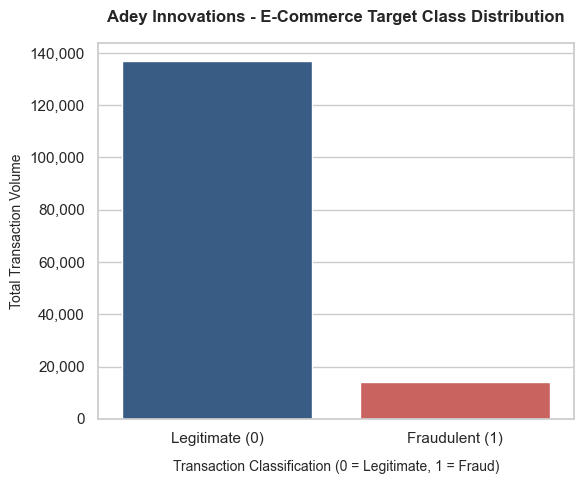

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean design style for our chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))

# Create the bar plot
ax = sns.countplot(x='class', data=ecom_df, palette=['#2b5c8f', '#d9534f'])

# Customize chart labels and titles
plt.title('Adey Innovations - E-Commerce Target Class Distribution', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Transaction Classification (0 = Legitimate, 1 = Fraud)', fontsize=10, labelpad=10)
plt.ylabel('Total Transaction Volume', fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraudulent (1)'])

# Format the numbers on the y-axis to look like standard counts (e.g., 100,000)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Display the chart safely in the notebook
plt.tight_layout()
plt.show()

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
RAW_DIR = "../data/raw/"

# Ingest both datasets
ecom_df = pd.read_csv(os.path.join(RAW_DIR, "Fraud_Data.csv"))
bank_df = pd.read_csv(os.path.join(RAW_DIR, "creditcard.csv"))

print("=========================================================")
print("             CLASS IMBALANCE QUANTIFICATION              ")
print("=========================================================")

# 1. E-Commerce Footprint
ecom_counts = ecom_df['class'].value_counts()
ecom_pct = ecom_df['class'].value_counts(normalize=True) * 100
print(f"--- E-Commerce Dataset (`Fraud_Data.csv`) ---")
print(f"Legitimate Transactions (0): {ecom_counts[0]:,} rows ({ecom_pct[0]:.2f}%)")
print(f"Fraudulent Transactions (1): {ecom_counts[1]:,} rows ({ecom_pct[1]:.2f}%)")
print(f"Imbalance Ratio: Approximately 1 fraud case per {int(ecom_counts[0]/ecom_counts[1])} normal sales.\n")

# 2. Bank Credit Card Footprint
bank_counts = bank_df['Class'].value_counts()
bank_pct = bank_df['Class'].value_counts(normalize=True) * 100
print(f"--- Bank Credit Card Dataset (`creditcard.csv`) ---")
print(f"Legitimate Transactions (0): {bank_counts[0]:,} rows ({bank_pct[0]:.4f}%)")
print(f"Fraudulent Transactions (1): {bank_counts[1]:,} rows ({bank_pct[1]:.4f}%)")
print(f"Imbalance Ratio: Approximately 1 fraud case per {int(bank_counts[0]/bank_counts[1])} normal swipes.")
print("=========================================================")

             CLASS IMBALANCE QUANTIFICATION              
--- E-Commerce Dataset (`Fraud_Data.csv`) ---
Legitimate Transactions (0): 136,961 rows (90.64%)
Fraudulent Transactions (1): 14,151 rows (9.36%)
Imbalance Ratio: Approximately 1 fraud case per 9 normal sales.

--- Bank Credit Card Dataset (`creditcard.csv`) ---
Legitimate Transactions (0): 284,315 rows (99.8273%)
Fraudulent Transactions (1): 492 rows (0.1727%)
Imbalance Ratio: Approximately 1 fraud case per 577 normal swipes.


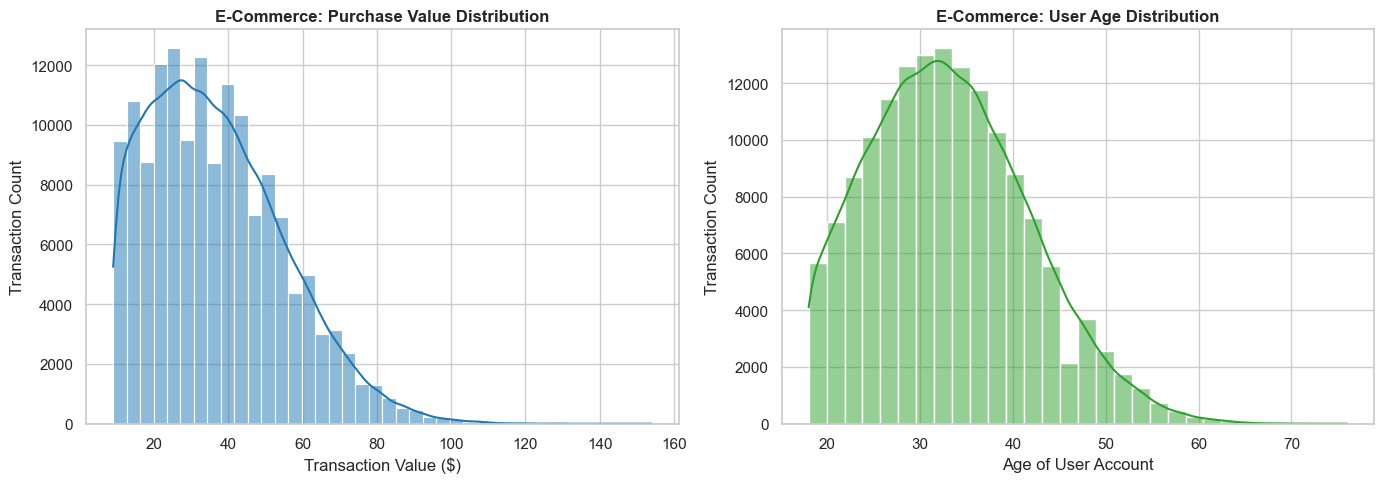

In [8]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Purchase Value Frequency Spectrum
sns.histplot(ecom_df['purchase_value'], bins=40, kde=True, color='#1f77b4', ax=axes[0])
axes[0].set_title('E-Commerce: Purchase Value Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Value ($)')
axes[0].set_ylabel('Transaction Count')

# Age Group Frequency Spectrum
sns.histplot(ecom_df['age'], bins=30, kde=True, color='#2ca02c', ax=axes[1])
axes[1].set_title('E-Commerce: User Age Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age of User Account')
axes[1].set_ylabel('Transaction Count')

plt.tight_layout()
plt.show()

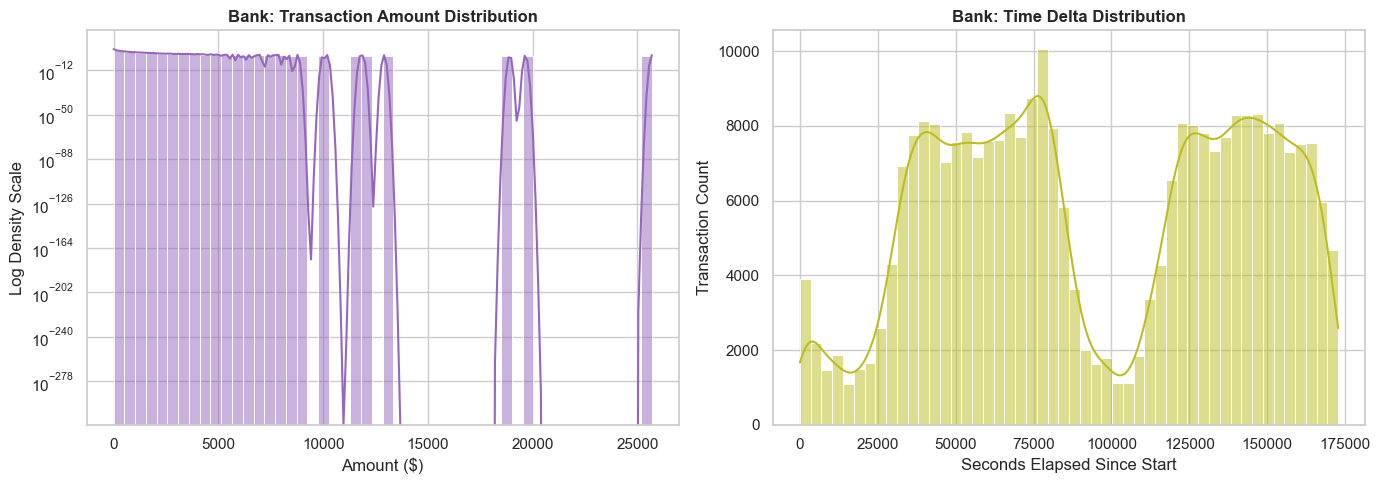

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction Amount Distribution
sns.histplot(bank_df['Amount'], bins=50, kde=True, color='#9467bd', ax=axes[0])
axes[0].set_title('Bank: Transaction Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Log Density Scale')
axes[0].set_yscale('log') # Log scale because a few huge transactions compress the small ones

# Transaction Time Distribution (seconds elapsed since the first recorded transaction)
sns.histplot(bank_df['Time'], bins=50, kde=True, color='#bcbd22', ax=axes[1])
axes[1].set_title('Bank: Time Delta Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Seconds Elapsed Since Start')
axes[1].set_ylabel('Transaction Count')

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_17452\624851771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='purchase_value', data=ecom_df, palette=['#1f77b4', '#d62728'], ax=axes[0])
C:\Users\HP\AppData\Local\Temp\ipykernel_17452\624851771.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_17452\624851771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='age', data=ecom_df, palette=['#1f77b4', '#d62728'], ax=axes[1])
C:\Users\HP\AppData\Local\Temp\ipykernel_17452\624851771.

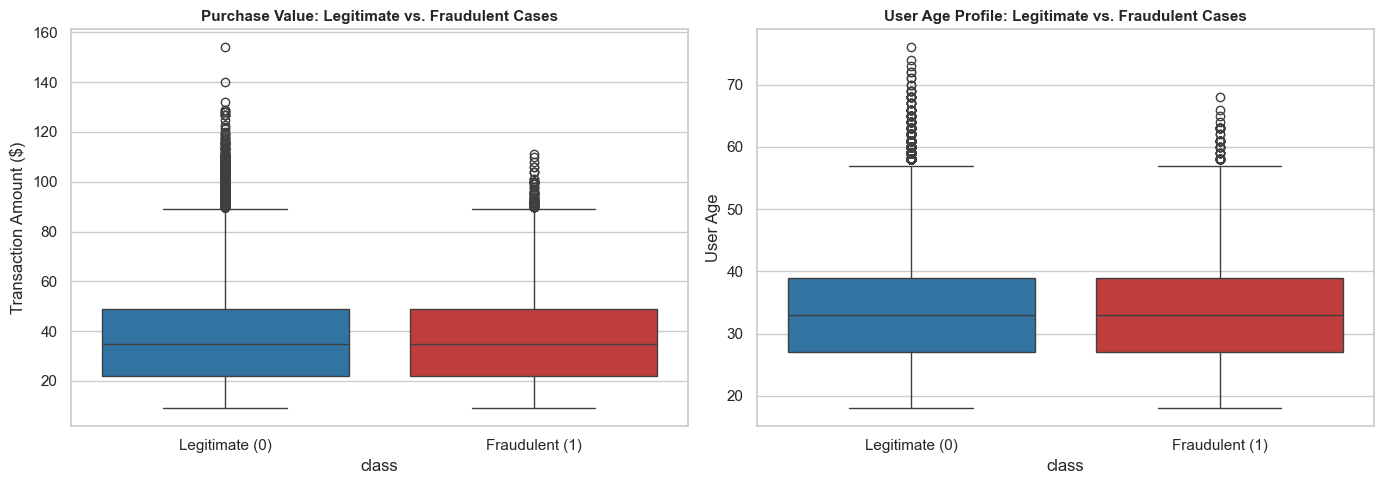

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Purchase values vs Target Class
sns.boxplot(x='class', y='purchase_value', data=ecom_df, palette=['#1f77b4', '#d62728'], ax=axes[0])
axes[0].set_title('Purchase Value: Legitimate vs. Fraudulent Cases', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
axes[0].set_ylabel('Transaction Amount ($)')

# User Age vs Target Class
sns.boxplot(x='class', y='age', data=ecom_df, palette=['#1f77b4', '#d62728'], ax=axes[1])
axes[1].set_title('User Age Profile: Legitimate vs. Fraudulent Cases', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
axes[1].set_ylabel('User Age')

plt.tight_layout()
plt.show()

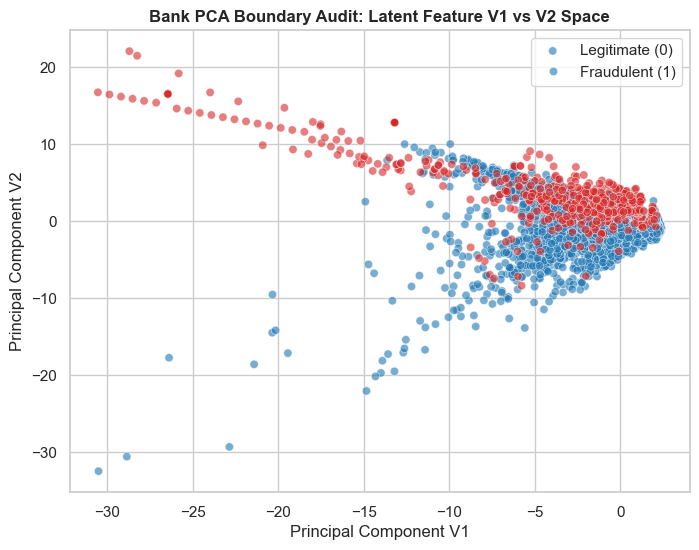

In [11]:
plt.figure(figsize=(8, 6))

# Sample a fraction of normal rows to avoid crashing your computer's rendering memory, but keep all rare fraud rows
legit_sample = bank_df[bank_df['Class'] == 0].sample(20000, random_state=42)
fraud_cases = bank_df[bank_df['Class'] == 1]
combined_sample = pd.concat([legit_sample, fraud_cases])

sns.scatterplot(x='V1', y='V2', hue='Class', data=combined_sample, palette=['#1f77b4', '#d62728'], alpha=0.6)
plt.title('Bank PCA Boundary Audit: Latent Feature V1 vs V2 Space', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component V1')
plt.ylabel('Principal Component V2')
plt.legend(labels=['Legitimate (0)', 'Fraudulent (1)'])
plt.show()

In [12]:
import os
import pandas as pd
import numpy as np

# Define paths
RAW_DIR = "../data/raw/"

# Ingest our translation map
ip_map_df = pd.read_csv(os.path.join(RAW_DIR, "IpAddress_to_Country.csv"))

print("--- Geolocation Reference Matrix Structure ---")
print(f"Total Range Blocks: {ip_map_df.shape[0]:,}")
display(ip_map_df.head())

--- Geolocation Reference Matrix Structure ---
Total Range Blocks: 138,846


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [13]:
# Force IP addresses to be clean, rounded 64-bit integers in both dataframes
ecom_df['ip_address'] = ecom_df['ip_address'].astype(np.int64)
ip_map_df['lower_bound_ip_address'] = ip_map_df['lower_bound_ip_address'].astype(np.int64)
ip_map_df['upper_bound_ip_address'] = ip_map_df['upper_bound_ip_address'].astype(np.int64)

print("[SUCCESS] Data types optimized. IP vectors cast to strict Int64 format.")

[SUCCESS] Data types optimized. IP vectors cast to strict Int64 format.


In [14]:
# Step 1: pd.merge_asof requires both dataframes to be sorted by the matching key column
ecom_sorted = ecom_df.sort_values('ip_address')
ip_map_sorted = ip_map_df.sort_values('lower_bound_ip_address')

# Step 2: Execute an intentional interval match
# It matches 'ip_address' to the nearest 'lower_bound_ip_address' that is less than or equal to it
merged_df = pd.merge_asof(
    ecom_sorted, 
    ip_map_sorted, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Step 3: Validation Step
# Because merge_asof only verifies the lower boundary, we must manually confirm 
# that the user's IP is also less than or equal to that country's upper boundary limit.
# If it is outside the upper limit, it means that IP belongs to an unassigned global space, so we mark it Unknown.
invalid_mask = merged_df['ip_address'] > merged_df['upper_bound_ip_address']
merged_df.loc[invalid_mask, 'country'] = 'Unknown'

# Fill any blank cells with 'Unknown' as a safeguard
merged_df['country'] = merged_df['country'].fillna('Unknown')

# Restore original row tracking integrity
ecom_df = merged_df.reset_index(drop=True)

print(f"[SUCCESS] Merging completed!")
print(f"Total transactions mapped to countries: {ecom_df['country'].nunique()}")
print(f"Transactions from unassigned spaces marked Unknown: {(ecom_df['country'] == 'Unknown').sum():,}")

[SUCCESS] Merging completed!
Total transactions mapped to countries: 182
Transactions from unassigned spaces marked Unknown: 21,966


In [15]:
# Group by country and calculate volume statistics
country_stats = ecom_df.groupby('country').agg(
    total_transactions=('class', 'count'),
    fraud_cases=('class', 'sum')
).reset_index()

# Calculate the precise fraud conversion rate per nation
country_stats['fraud_rate_%'] = (country_stats['fraud_cases'] / country_stats['total_transactions']) * 100

# Filter for countries with relevant transaction volumes (>100) to avoid skewed metrics
significant_countries = country_stats[country_stats['total_transactions'] >= 100]

# Sort to isolate the highest percentage risk zones
top_fraud_hotspots = significant_countries.sort_values(by='fraud_rate_%', ascending=False).head(10)

print("==================================================================")
print("             TOP 10 HIGHEST RISK GEOGRAPHIC ZONES                 ")
print("==================================================================")
display(top_fraud_hotspots)
print("==================================================================")

             TOP 10 HIGHEST RISK GEOGRAPHIC ZONES                 


,country,total_transactions,fraud_cases,fraud_rate_%
51,Ecuador,106,28,26.415094
164,Tunisia,118,31,26.271186
131,Peru,119,31,26.050420
80,Ireland,240,55,22.916667
120,New Zealand,278,62,22.302158
144,Saudi Arabia,264,50,18.939394
47,Denmark,490,78,15.918367
35,Chile,417,64,15.347722
67,Greece,231,33,14.285714
169,United Arab Emirates,114,16,14.035088


C:\Users\HP\AppData\Local\Temp\ipykernel_17452\2633127916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_17452\2633127916.py:4: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.barplot(


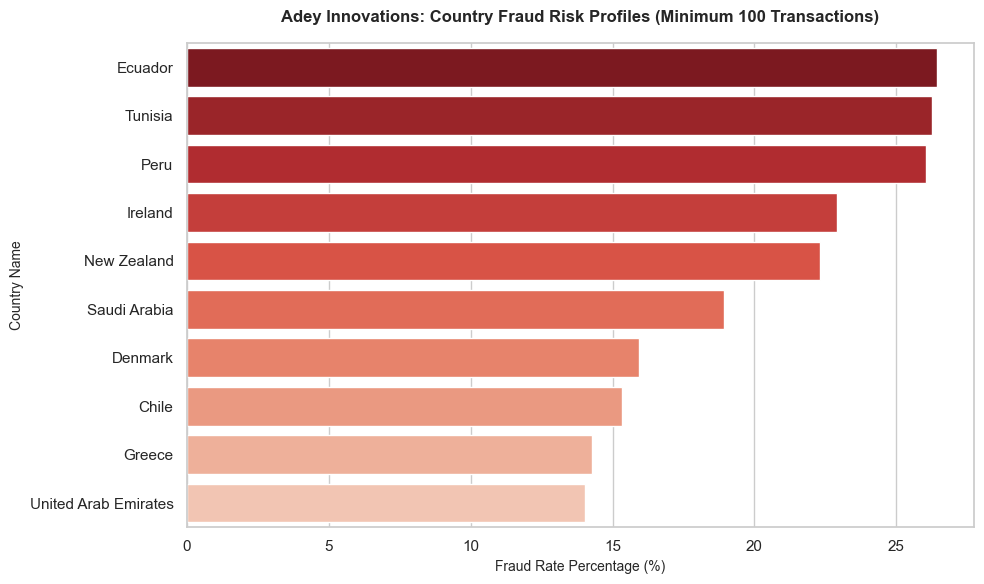

In [16]:
plt.figure(figsize=(10, 6))

# Create the visualization chart
sns.barplot(
    x='fraud_rate_%', 
    y='country', 
    data=top_fraud_hotspots, 
    palette=sns.color_palette("Reds_r", n_colors=12)
)

plt.title('Adey Innovations: Country Fraud Risk Profiles (Minimum 100 Transactions)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Fraud Rate Percentage (%)', fontsize=10)
plt.ylabel('Country Name', fontsize=10)
plt.tight_layout()
plt.show()